# V4 — Process evaluation

Pointwise skill (RMSE) and physical-consistency skill measure different things: a smoothed model can match the truth in RMSE while breaking geostrophic balance and conservation budgets. This notebook demonstrates the V4 metrics on a synthetic geostrophic flow plus a smoothed twin.

Sections:
1. Build a synthetic SSH + geostrophic (u, v) on a lon/lat grid.
2. Smooth the twin and confirm RMSE is small.
3. `GeostrophicBalanceError` — residuals grow on the smoothed twin.
4. `DivergenceError` — surface 2-D divergence.
5. `DensityInversionFraction` on a synthetic stable column.
6. `grid_metrics_from_coords` + `HeatBudgetResidual` on a closed (constant-tracer) toy budget.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from xr_toolz import calc, metrics, ocn
from xr_toolz.budgets import HeatBudgetResidual

## 1 — Synthetic geostrophic flow

In [2]:
lon = np.linspace(-30.0, 30.0, 121)
lat = np.linspace(20.0, 50.0, 61)
LON, LAT = np.meshgrid(lon, lat, indexing='xy')
ssh_truth = 0.1 * np.sin(np.deg2rad(2 * LON)) * np.cos(np.deg2rad(LAT))
ssh = xr.DataArray(ssh_truth, coords={'lat': lat, 'lon': lon}, dims=('lat', 'lon'), name='ssh')
ds_truth = ocn.geostrophic_velocities(ssh.to_dataset(), variable='ssh')
ds_truth['ssh'] = ssh
ds_truth

<xarray.Dataset> Size: 179kB
Dimensions:  (lat: 61, lon: 121)
Coordinates:
  * lat      (lat) float64 488B 20.0 20.5 21.0 21.5 22.0 ... 48.5 49.0 49.5 50.0
  * lon      (lon) float64 968B -30.0 -29.5 -29.0 -28.5 ... 28.5 29.0 29.5 30.0
Data variables:
    u        (lat, lon) float64 59kB -0.000925 -0.0009155 ... 0.0009107
    v        (lat, lon) float64 59kB 0.003132 0.003179 ... 0.001419 0.001399
    ssh      (lat, lon) float64 59kB -0.08138 -0.08055 ... 0.0551 0.05567

## 2 — Smoothed twin

In [3]:
def smooth_da(da, sigma=2.0):
    return xr.DataArray(gaussian_filter(da.values, sigma=sigma), coords=da.coords, dims=da.dims, name=da.name)

ds_smooth = xr.Dataset({k: smooth_da(ds_truth[k], sigma=2.0) for k in ['ssh', 'u', 'v']})
rmse_ssh = float(metrics.rmse(ds_smooth, ds_truth, variable='ssh', dims=('lat', 'lon')))
print(f'RMSE(ssh): {rmse_ssh:.4e}')

RMSE(ssh): 1.4549e-04


## 3 — Geostrophic-balance residuals

max |r_u| (truth):    1.323e-23
max |r_u| (smoothed): 8.545e-10


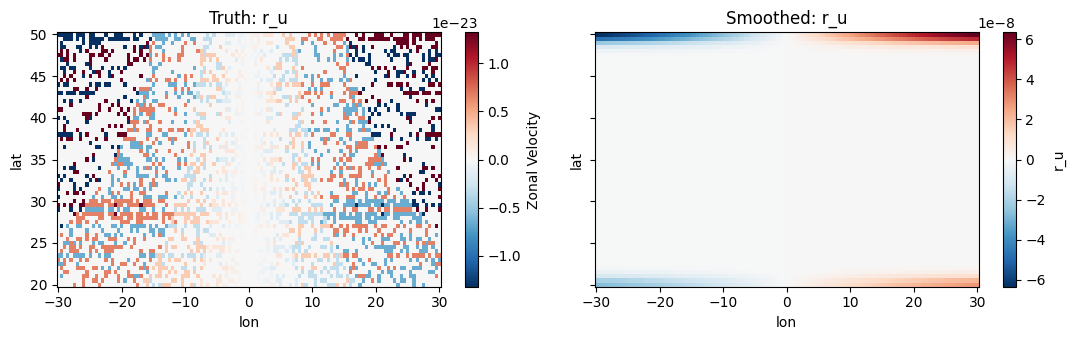

In [4]:
res_truth = metrics.geostrophic_balance_error(ds_truth)
res_smooth = metrics.geostrophic_balance_error(ds_smooth)
interior = {'lat': slice(5, -5), 'lon': slice(5, -5)}
print(f"max |r_u| (truth):    {float(np.abs(res_truth['r_u'].isel(interior)).max()):.3e}")
print(f"max |r_u| (smoothed): {float(np.abs(res_smooth['r_u'].isel(interior)).max()):.3e}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
res_truth['r_u'].plot(ax=axes[0]); axes[0].set_title('Truth: r_u')
res_smooth['r_u'].plot(ax=axes[1]); axes[1].set_title('Smoothed: r_u')
fig.tight_layout(); plt.show()

## 4 — Divergence error

In [5]:
div_truth = metrics.divergence_error(ds_truth)
div_smooth = metrics.divergence_error(ds_smooth)
print(f'std(div_truth):    {float(div_truth.std()):.3e}')
print(f'std(div_smoothed): {float(div_smooth.std()):.3e}')

std(div_truth):    5.566e-10
std(div_smoothed): 4.807e-10


## 5 — Density-inversion fraction (synthetic column)

In [6]:
depth = np.linspace(0.0, 1000.0, 11)
rho_stable = 1020.0 + 0.005 * depth
rho_inv = rho_stable.copy(); rho_inv[5] = rho_inv[4] - 0.05
for label, rho in [('stable', rho_stable), ('one inversion', rho_inv)]:
    da = xr.DataArray(rho, coords={'depth': depth}, dims=('depth',))
    print(f'{label:>15s}: {float(metrics.density_inversion_fraction(da.to_dataset(name="rho"))):.3f}')

         stable: 0.000
  one inversion: 0.100


## 6 — Heat-budget residual (closed toy)

Closed-budget sanity check: a constant tracer with zero velocity has zero residual. Real budgets break closure as the model adds advection and forcing.

In [7]:
time = np.arange(3)
shape = (time.size, lat.size, lon.size)
ds_budget = xr.Dataset(
    {
        'theta': (('time', 'lat', 'lon'), np.full(shape, 15.0)),
        'u':     (('time', 'lat', 'lon'), np.zeros(shape)),
        'v':     (('time', 'lat', 'lon'), np.zeros(shape)),
    },
    coords={'time': time, 'lat': lat, 'lon': lon},
)
vol, face = calc.grid_metrics_from_coords(ds_budget)
op = HeatBudgetResidual(temp_var='theta', depth=None)
residual = op(ds_budget)
print(f'max |residual|: {float(np.abs(residual).max()):.3e}')

max |residual|: 0.000e+00
